In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from numpy.linalg import solve

np.random.seed(1)

import warnings
warnings.filterwarnings('ignore')


## Linear Regression

### Housing Dataset

We consider the [Kings County housing dataset](https://www.kaggle.com/datasets/harlfoxem/housesalesprediction). It includes homes sold between May 2014 and May 2015.

Specifically, we focuse on the Rainier Valley zipcode.

In [3]:
# Load the dataset
house = pd.read_csv("data/rainier_valley_house.csv")

In [4]:
house.columns

Index(['Unnamed: 0', 'id', 'date', 'price', 'bedrooms', 'bathrooms',
       'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition',
       'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [5]:
# We will consider this subset of features
features = ["floors", "grade", "condition", "view", "sqft_living",
            "sqft_lot", "sqft_basement", "yr_built", "yr_renovated",
            "bedrooms", "bathrooms", "lat", "long"]

house = house[house['price'] < 1e6]

Y = house['price'] / 1000
X = house[features]

## Standardize the features
scaler = StandardScaler()
X_stan = scaler.fit_transform(X)

### Linear Regression Formula

We compute the regression coefficients using the formula:

$$\widehat{\beta} = (X^\top X)^{-1}X^\top y$$

In [6]:
## linear regression
X_stan1 = np.hstack([np.ones((X_stan.shape[0], 1)), X_stan])
X_train, X_test, Y_train, Y_test = train_test_split(X_stan1, Y, test_size=100, train_size=400, random_state=2)

betahat = np.linalg.inv(X_train.T @ X_train) @ (X_train.T @ Y_train)
Y_pred = X_test @ betahat

test_error = np.sqrt(((Y_test - Y_pred) ** 2).mean())
baseline_error = np.sqrt(((Y_test - Y_train.mean()) ** 2).mean())

## print coefficients
print("Coefficients:")
features_list = ['Intercept'] + list(X.columns)
for i, f in enumerate(features_list):
    print(f"{f}: {betahat[i]:.3f}")


print(f"Test RMSE of linear regression: {test_error:.3f}   Baseline RMSE: {baseline_error:.3f}")

R2 = 1 - test_error**2 / baseline_error**2
print(f"Test R-squared of linear regression: {R2:.3f}")


Coefficients:
Intercept: 397.667
floors: 7.706
grade: 44.060
condition: 17.140
view: 27.275
sqft_living: 72.711
sqft_lot: 12.589
sqft_basement: -12.538
yr_built: -13.716
yr_renovated: 2.193
bedrooms: -19.933
bathrooms: 10.003
lat: 70.999
long: 29.816
Test RMSE of linear regression: 84.774   Baseline RMSE: 151.875
Test R-squared of linear regression: 0.688


### Using `statsmodels`

We can also use `statsmodels` to run linear regression for us:

In [7]:
import statsmodels.api as sm

model = sm.OLS(Y_train, X_train)
results = model.fit()

In [8]:
results.params

const    397.666919
x1         7.705884
x2        44.059690
x3        17.140391
x4        27.274524
x5        72.711224
x6        12.589442
x7       -12.538127
x8       -13.716293
x9         2.192980
x10      -19.933029
x11       10.002684
x12       70.999486
x13       29.815873
dtype: float64

In [9]:
coeffs = results.params

In [10]:
Y_pred = results.get_prediction(X_test)
Y_pred = Y_pred.predicted_mean

test_error = np.sqrt(((Y_test - Y_pred) ** 2).mean())
baseline_error = np.sqrt(((Y_test - Y_train.mean()) ** 2).mean())

print(f"Test RMSE of linear regression: {test_error:.3f}   Baseline RMSE: {baseline_error:.3f}")

R2 = 1 - test_error**2 / baseline_error**2
print(f"Test R-squared of linear regression: {R2:.3f}")

Test RMSE of linear regression: 84.774   Baseline RMSE: 151.875
Test R-squared of linear regression: 0.688


### Inference

#### t-tests for coefficients

In [11]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.729
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     79.91
Date:                Fri, 13 Feb 2026   Prob (F-statistic):          8.70e-101
Time:                        16:04:41   Log-Likelihood:                -2349.3
No. Observations:                 400   AIC:                             4727.
Df Residuals:                     386   BIC:                             4783.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        397.6669      4.393     90.528      0.000     389.030     406.304
x1             7.7059      6.882      1.120      0.264      -5.826      21.238
x2            44.0597      7.045      6.254      0.000      30.209      57.911
x3            17.1404      4.790      3.579      0.000       7.723      26.557
x4            27.2745      4.999      5.456      0.000      17.446      37.103
x5            72.7112     10.910      6.665      0.000      51.261      94.161
x6            12.5894      5.318      2.367      0.018       2.133      23.046
x7           -12.5381      7.710     -1.626      0.105     -27.696       2.620
x8           -13.7163      6.625     -2.070      0.039     -26.742      -0.690
x9             2.1930      4.533      0.484      0.629      -6.720      11.106
x10          -19.9330      6.492     -3.071      0.002     -32.697      -7.169
x11           10.0027      8.088      1.237      0.217      -5.899      25.904
x12           70.9995      5.221     13.599      0.000      60.735      81.264
x13           29.8159      5.281      5.646      0.000      19.434      40.198
==============================================================================
Omnibus:                       26.158   Durbin-Watson:                   1.973
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               65.389
Skew:                           0.285   Prob(JB):                     6.32e-15
Kurtosis:                       4.897   Cond. No.                         6.12
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [12]:
# Extract confidence intervals from the summary table
conf_int = results.conf_int()

#### Using the bootstrap

In [13]:
Y_train = Y_train.to_numpy()
n_train = X_train.shape[0]

beta = coeffs

n_boot = 1000

bootstrap_inds = [np.random.choice(range(1, n_train), n_train, replace=True) for _ in range(n_boot)]

boot_bhats = np.zeros((n_boot, X_train.shape[1]))
for b in range(n_boot):
    X_boot = X_train[bootstrap_inds[b]]
    Y_boot = Y_train[bootstrap_inds[b]]
    linreg = sm.OLS(Y_boot, X_boot)
    boot_result = linreg.fit()
    boot_bhats[b, :] = boot_result.params

![](fig/boot_linreg.gif)

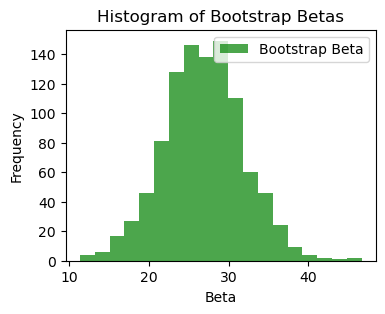

In [14]:
bins_beta = np.linspace(boot_bhats[:, 4].min(), boot_bhats[:, 4].max(), 20)

plt.figure(figsize=(4,3))
plt.hist(boot_bhats[:, 4], bins=bins_beta, alpha=0.7, color='green', label='Bootstrap Beta')
plt.title('Histogram of Bootstrap Betas')
plt.xlabel('Beta')
plt.ylabel('Frequency')
plt.legend()

In [15]:
beta_sds = np.std(boot_bhats, axis=0)

In [16]:
# confidence interval
lower_quantiles = beta - 2 * beta_sds
upper_quantiles = beta + 2 * beta_sds

# Print results
print("95% Bootstrap Confidence Intervals for Coefficients:")
for i, f in enumerate(features_list):
    print(f"{f}: ({lower_quantiles[i]:.3f}, {upper_quantiles[i]:.3f})")

95% Bootstrap Confidence Intervals for Coefficients:
Intercept: (388.878, 406.456)
floors: (-6.717, 22.129)
grade: (27.224, 60.895)
condition: (7.662, 26.619)
view: (17.276, 37.273)
sqft_living: (48.540, 96.882)
sqft_lot: (-1.782, 26.961)
sqft_basement: (-29.503, 4.427)
yr_built: (-29.000, 1.567)
yr_renovated: (-7.993, 12.379)
bedrooms: (-35.586, -4.280)
bathrooms: (-7.101, 27.106)
lat: (60.028, 81.971)
long: (19.281, 40.350)


## Overfitting 

### Example with $n=p$

In [17]:
## Simulate data from linear model
p = 30
n_train = 30
n_test = 100
n = n_train + n_test

beta_true = 1/np.sqrt(p) * np.ones(p)

X = np.random.normal(size=(n, p))
noise = 0.5 * np.random.normal(size=(n))
Y = X @ beta_true + noise

X_train = X[:n_train, :]
Y_train = Y[:n_train]
X_test = X[n_train:, :]
Y_test = Y[n_train:]

betahat = np.linalg.solve(X_train.T @ X_train,  X_train.T @ Y_train)

## print training error
train_error = np.mean((Y_train - X_train @ betahat)**2) 
print(f"Training error: {train_error:.2f}")

## print test error
test_error = np.mean((Y_test - X_test @ betahat)**2)
print(f"Test error: {test_error:.2f}")

Training error: 0.00
Test error: 8.11


### Example with polynomials 

Training error: 0.01


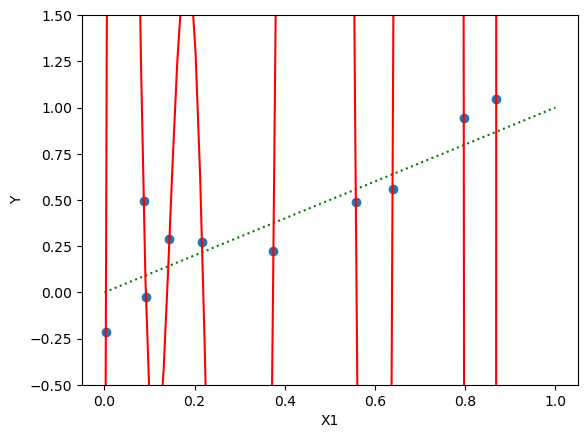

In [18]:
n = 10
X1 = np.random.uniform(size=(n))
noise = 0.2 * np.random.normal(size=(n))
Y = X1 + noise

## add polynomial of X1
p = 10
X = np.column_stack([X1**i for i in range(0, p+1)])


## fit linear model
betahat = np.linalg.solve(X.T @ X, X.T @ Y)

err = np.sum((Y - X @ betahat)**2)
print(f"Training error: {err:.2f}")


# plot X1, Y
import matplotlib.pyplot as plt
plt.scatter(X1, Y)
plt.xlabel('X1')
plt.ylabel('Y')
X1_grid = np.linspace(0, 1, 100)

# plot truth as dotted
Y_grid = X1_grid
plt.plot(X1_grid, Y_grid, color='green', linestyle='dotted')

# plot fitted curve
X_grid = np.column_stack([X1_grid**i for i in range(0, p+1)])
Y_grid = X_grid @ betahat
plt.ylim(-.5, 1.5)
plt.plot(X1_grid, Y_grid, color='red')

plt.show()

Some coefficients are very large:

In [19]:
-np.sort(-betahat)  # np.sort is smallest to largest - use negative for largest to smallest

array([ 2.75524984e+07,  7.25216625e+06,  3.51473556e+06,  3.01842642e+05,
        1.01149788e+03, -2.54649723e+00, -2.80791410e+04, -7.56886527e+05,
       -1.53581036e+06, -1.31515994e+07, -2.31322672e+07])

## Linear Regression with Ridge Regularization

Ridge regularization shrinks coefficients $\beta$. The formula is:

$$\widehat{\beta} = (X^\top X + \lambda \bm{I})^{-1}X^\top y$$

We now consider a movies dataset where we want to predict revenue from the genre and other features.

Number of features: 16
Coefficients: 
Intercept: 176.04
Action: -11.09
Crime: -6.64
Comedy: -5.66
Adventure: 25.45
Drama: -19.20
Fantasy: 9.59
Foreign: -4.93
Music: -1.61
Western: -5.70
Science Fiction: 13.80
Mystery: -1.23
Family: 15.01
Horror: 5.08
Romance: 1.78
runtime: 45.09
budget: 139.72
Test Error: 163.43
Baseline Error: 260.98
Test R-squared: 0.61


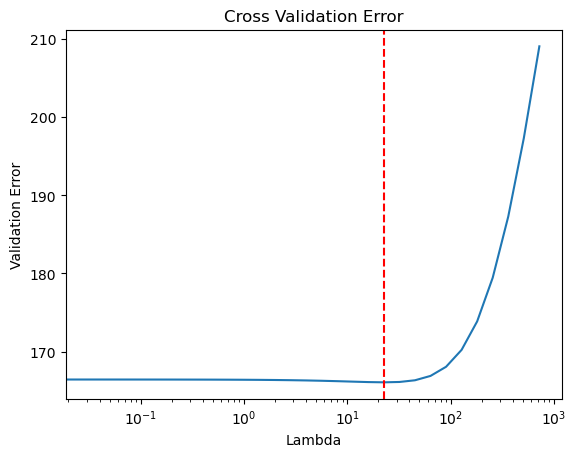

In [20]:
# Load the dataset
movies = pd.read_csv("data/movies.csv")

## permute rows 
np.random.seed(1)
movies = movies.sample(frac=1).reset_index(drop=True)

## remove rows with 0 revenue
movies = movies[movies['revenue'] > 0]

movies = movies.dropna()

# List of features
features = ["Action", "Crime", "Comedy",
             "Adventure", "Drama", "Fantasy", "Foreign", "Music", "Western",
             "Science Fiction", "Mystery", "Family", "Horror", "Romance", 
             "runtime", "budget"]

# Target variable
Y = movies['revenue']/1000000
X = movies[features]

# add interaction between first 10 features and budget
# for feature in features[:10]:
#     X[feature + ':budget'] = X[feature] * X['budget']
# features = X.columns

print(f"Number of features: {X.shape[1]}")

scaler = StandardScaler()
X_stan = scaler.fit_transform(X)

# Add a column of ones to include the intercept in the model
X_stan = np.hstack([np.ones((X_stan.shape[0], 1)), X_stan])

# Split the data into test, learning (further divided into train and validation), and training sets
n_learn = 600
n_test = 300

Y_test = Y.iloc[:n_test]
Y_learn = Y.iloc[n_test:n_test+n_learn]

X_test = X_stan[:n_test, :]
X_learn = X_stan[n_test:n_test+n_learn, :]

# Candidate set for lambda
candidate_set = np.concatenate([[0], 2 ** np.arange(-5, 10, .5)])

K = 10

indices = np.arange(n_learn)
folds = indices.reshape(K, -1)

validerr = np.zeros((K, len(candidate_set)))

for k in range(K):
    valid_ix = folds[k, :]
    train_ix = np.delete(indices, folds[k, :])

    X_valid = X_learn[valid_ix, :]
    Y_valid = Y_learn.iloc[valid_ix]
    X_train = X_learn[train_ix, :]
    Y_train = Y_learn.iloc[train_ix]

    for j, lambda_val in enumerate(candidate_set):

        beta_lambda = solve(X_train.T @ X_train + lambda_val * np.eye(X_train.shape[1]), 
                            X_train.T @ Y_train)
        
        Y_lambda = X_valid @ beta_lambda

        validerr[k, j] = np.sqrt(np.mean((Y_valid - Y_lambda) ** 2))

mean_valid_errs = validerr.mean(axis=0)
min_ix = np.argmin(mean_valid_errs)

lambda_best = candidate_set[min_ix]

beta_best = solve(X_learn.T @ X_learn + lambda_best * np.eye(X_learn.shape[1]), 
                  X_learn.T @ Y_learn)

Y_pred = X_test @ beta_best
Y_baseline = Y_learn.mean()

## print coefficients
print("Coefficients: ")
print(f"Intercept: {beta_best[0]:.2f}")
for i in range(len(features)):
    print(f"{features[i]}: {beta_best[i+1]:.2f}")

# Evaluate test error
test_error = np.sqrt(np.mean((Y_test - Y_pred) ** 2))
baseline_error = np.sqrt(np.mean((Y_test - Y_baseline) ** 2))

## print errors and R^2 with 2 sig figs
print("Test Error: {:.2f}".format(test_error))
print("Baseline Error: {:.2f}".format(baseline_error))
print("Test R-squared: {:.2f}".format(1 - test_error ** 2 / baseline_error ** 2))


## plot cross validation errors
import matplotlib.pyplot as plt
plt.plot(candidate_set, mean_valid_errs)
plt.axvline(x=lambda_best, color='r', linestyle='--')
plt.xlabel("Lambda")
plt.ylabel("Validation Error")
plt.title("Cross Validation Error")
plt.xscale('log')
plt.show()
